In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df = pd.read_csv(r"C:\Users\PC\Desktop\image\House Price Prediction Dataset.csv")

In [8]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [9]:
df.shape

(2000, 10)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [13]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [14]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [15]:
# To remove unneccessary columns
df = df.drop("Id", axis=1)

In [16]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [17]:
# separating Features from target
x = df.drop("Price", axis=1)
y = df["Price"]

In [18]:
# Find the Word in Columns
categorical_features = ["Location", "Condition", "Garage"]

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)
    

In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# build the machine learning Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [24]:
#train the Model
model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
# Make predictions
y_pred = model.predict(x_test)
y_pred[:10]

array([646493.96 , 492693.25 , 529740.81 , 476972.265, 511690.13 ,
       558213.57 , 520595.185, 601217.86 , 614763.49 , 650600.78 ])

In [31]:
# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae) # Average prediction error
print("RMSE:", rmse) # Penalizes large errors
print("R2 Score:", r2) # Model accuracy (closer to 1 is better).

MAE : 252318.80585
RMSE: 292191.87369688397
R2 Score: -0.09739558652426616


In [34]:
# Feature Importance
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
10,remainder__Area,0.315038
14,remainder__YearBuilt,0.256462
11,remainder__Bedrooms,0.089291
12,remainder__Bathrooms,0.068571
13,remainder__Floors,0.045711
1,cat__Location_Rural,0.025466
3,cat__Location_Urban,0.024302
0,cat__Location_Downtown,0.023993
5,cat__Condition_Fair,0.023626
7,cat__Condition_Poor,0.023490


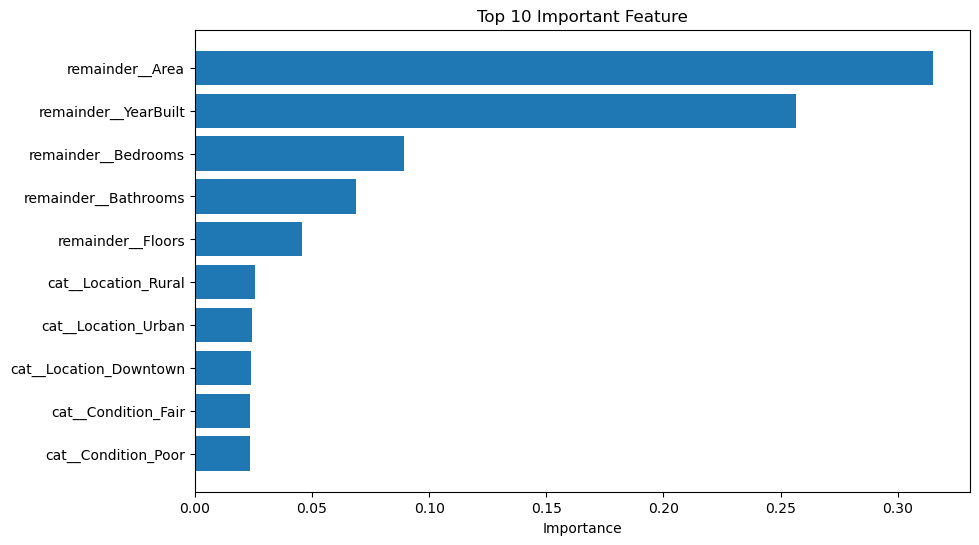

In [37]:
# Plot Feature Importance
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Important Feature")
plt.xlabel("Importance")
plt.show()

In [39]:
#Predict the Price of a New House
new_house = pd.DataFrame({
    "Area":[2500],
    "Bedrooms":[3],
    "Bathrooms":[2],
    "Floors":[2],
    "YearBuilt":[2018],
    "Location":["Downtown"],
    "Condition":["Excellent"],
    "Garage":["Yes"]
})

predicted_price = model.predict(new_house)

print("Predicted House Price: ${:,.2f}".format(predicted_price[0]))
        

Predicted House Price: $484,816.04
